
Author: Turbat Turkhuu

Date: March 2026

- Disclaimer: All data used in this report are publicly available and there are no data restrictions involved


# Overview

This report provides a comprehensive analysis of solar adoption trends across Australia from 2011 to 2026. 

By examining historical installation volumes, overall solar capacity and population data. This report uncovers insights designed to assist the Australian Renewable Energy Agency (ARENA) in optimizing their strategic investments and policy support. 


# Executive Summary 
This report analyses the growth of solar energy adoption in Australia from 2011 onwards, focusing on installations and capacity per 100,000 people. Data was collected from multiple CSV datasets and processed using Python and the Pandas library within a Jupyter Notebook environment.

The analysis shows a substantial increase in both solar installations and total capacity over time. When normalised per capita, the results demonstrate consistent growth, indicating that adoption is not solely driven by population increase but by rising demand and accessibility.

Solar capacity per 100,000 people has grown faster than installation rates, suggesting that average system sizes have increased over time. This reflects improvements in solar technology and affordability.

The findings highlight the effectiveness of renewable energy policies and suggest continued growth potential. Recommendations include targeted regional investment, continued policy support, and further analysis of state-level trends.


In [1]:
%pip install pandas
import pandas as pd
df_solar = pd.read_csv('sgu-solar-installations-2011-to-present-and-totals.csv')
df_capacity = pd.read_csv('sgu-solar-capacity-2011-to-present-and-totals.csv')
df_population = pd.read_csv('Australian-Population-1981.csv')
df_state_pop = pd.read_csv('State-Population-1981.csv')

df_solar = df_solar.reset_index()

df_solar_long = df_solar.melt(
    id_vars="Small Unit Installation Postcode",
    var_name="Date",
    value_name="Installations"
)

df_solar_long = df_solar_long[
    df_solar_long["Date"].str.contains("Installation Quantity")
]
df_solar_long["Date"] = df_solar_long["Date"].str.replace(" - Installation Quantity", "", regex=False)
df_solar_long["Date"] = pd.to_datetime(df_solar_long["Date"], errors="coerce")
df_solar_long.head()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\tturb\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip
C:\Users\tturb\AppData\Local\Temp\ipykernel_22444\378753050.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_solar = df_solar.reset_index()
C:\Users\tturb\AppData\Local\Temp\ipykernel_22444\378753050.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_solar_long["Date"] = pd.to_datetime(df_solar_long["Date"], errors="coerce")


,Small Unit Installation Postcode,Date,Installations
2810,0,NaT,4
2811,200,NaT,1
2812,800,NaT,7
2813,801,NaT,2
2814,803,NaT,0


In [2]:
df_capacity = df_capacity.rename(columns={"Small Unit Postcode": "Postcode"})
df_capacity = df_capacity.reset_index()

df_capacity_long = df_capacity.melt(
    id_vars="Postcode",
    var_name="Date",
    value_name="Capacity_kW"
)

df_capacity_long = df_capacity_long[
    df_capacity_long["Date"].str.contains("Rated Power Output")
]

df_capacity_long["Date"] = df_capacity_long["Date"].str.replace(" - Rated Power Output In kW", "", regex=False)
df_capacity_long["Date"] = pd.to_datetime(df_capacity_long["Date"], errors="coerce")

df_capacity_long.head()

solar_yearly = df_solar_long.copy()
solar_yearly["Year"] = solar_yearly["Date"].dt.year

solar_yearly = solar_yearly.groupby("Year")["Installations"].sum().reset_index()

capacity_yearly = df_capacity_long.copy()
capacity_yearly["Year"] = capacity_yearly["Date"].dt.year

capacity_yearly = capacity_yearly.groupby("Year")["Capacity_kW"].sum().reset_index()

C:\Users\tturb\AppData\Local\Temp\ipykernel_22444\3952264148.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_capacity = df_capacity.reset_index()
C:\Users\tturb\AppData\Local\Temp\ipykernel_22444\3952264148.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_capacity_long["Date"] = pd.to_datetime(df_capacity_long["Date"], errors="coerce")


In [3]:
def postcode_to_state(pc):
    try:
        pc = int(pc)
    except (ValueError, TypeError):
        return None
    if 1000 <= pc <= 2999:
        return "New South Wales"
    elif 3000 <= pc <= 3999:
        return "Victoria"
    elif 4000 <= pc <= 4999:
        return "Queensland"
    elif 5000 <= pc <= 5999:
        return "South Australia"
    elif 6000 <= pc <= 6999:
        return "Western Australia"
    elif 7000 <= pc <= 7999:
        return "Tasmania"
    elif 800 <= pc <= 899:
        return "Northern Territory"
    elif 200 <= pc <= 299:
        return "Australian Capital Territory"
    else:
        return None

df_state = df_state_pop[df_state_pop["Year"].str.contains("Dec")].reset_index(drop=True)
df_state.columns = df_state.columns.str.strip()
df_state.columns = df_state.columns.str.replace("Estimated Resident Population ; ", "", regex=False)
df_state.columns = df_state.columns.str.replace(" ;", "", regex=False)

persons_cols = [c for c in df_state.columns if "Persons" in c]
df_state = df_state[["Year"] + persons_cols].copy()

df_state.columns = ["Year"] + [
    c.replace("Persons", "").strip() for c in persons_cols
]

df_state["Year"] = df_state["Year"].str.replace("Dec-", "", regex=False).astype(int)
df_state = df_state.set_index("Year")

df_state = df_state.apply(pd.to_numeric, errors="coerce")

df_solar_long["State"] = df_solar_long["Small Unit Installation Postcode"].apply(postcode_to_state)
df_solar_long["Year"] = df_solar_long["Date"].dt.year

df_solar_state = (
    df_solar_long.dropna(subset=["State", "Year"])
    .groupby(["State", "Year"])["Installations"]
    .sum()
    .reset_index()
)

df_capacity_long["State"] = df_capacity_long["Postcode"].apply(postcode_to_state)
df_capacity_long["Year"] = df_capacity_long["Date"].dt.year

df_capacity_state = (
    df_capacity_long.dropna(subset=["State", "Year"])
    .groupby(["State", "Year"])["Capacity_kW"]
    .sum()
    .reset_index()
)

df_pop_long = df_state.reset_index().melt(id_vars="Year", var_name="State", value_name="Population")

df_state_final = df_solar_state.merge(df_capacity_state, on=["State", "Year"])
df_state_final = df_state_final.merge(df_pop_long, on=["State", "Year"])
df_state_final = df_state_final[df_state_final["Year"] >= 2011].copy()

df_state_final["Installations_per_100k"] = (
    df_state_final["Installations"] / df_state_final["Population"]
) * 100_000

df_state_final["Capacity_per_100k"] = (
    df_state_final["Capacity_kW"] / df_state_final["Population"]
) * 100_000


# Introduction 
The objective of this analysis is to evaluate the growth of solar energy adoption in Australia by examining installation rates and total solar capacity relative to population size.

The study focuses on the period from 2011 onwards, as this marks the beginning of large-scale solar uptake in Australia.

Data Sources:
- Solar installation dataset 
- Solar capacity dataset 
- Australian population data

Tools Used:
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

# Methodology 
 Data was reshaped, cleaned, and aggregated to state level, then normalised per capita.


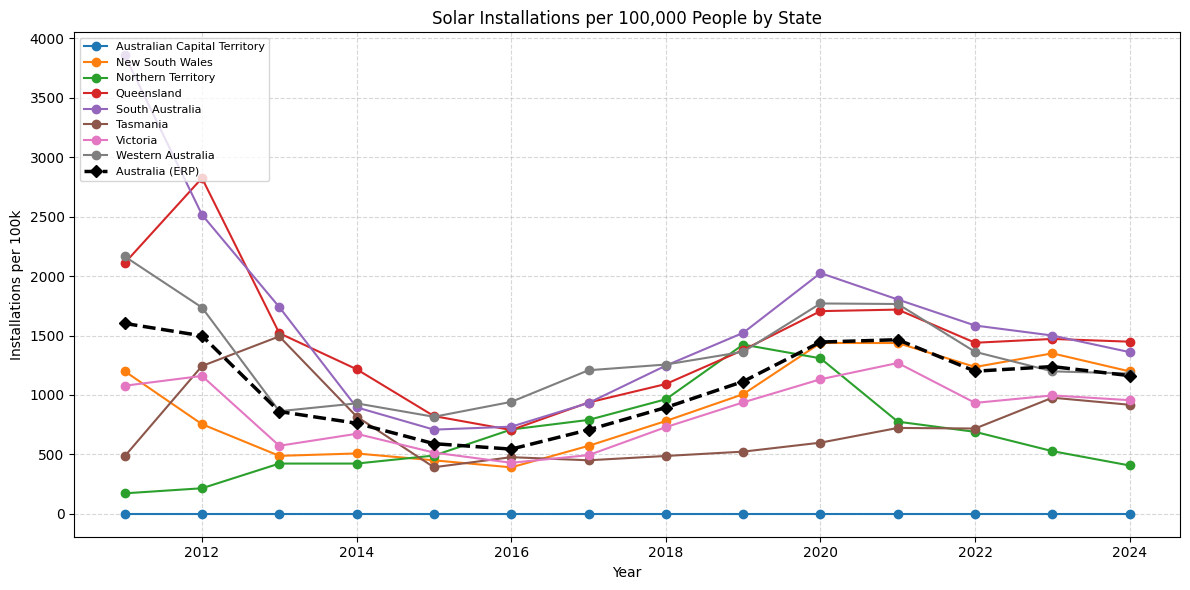

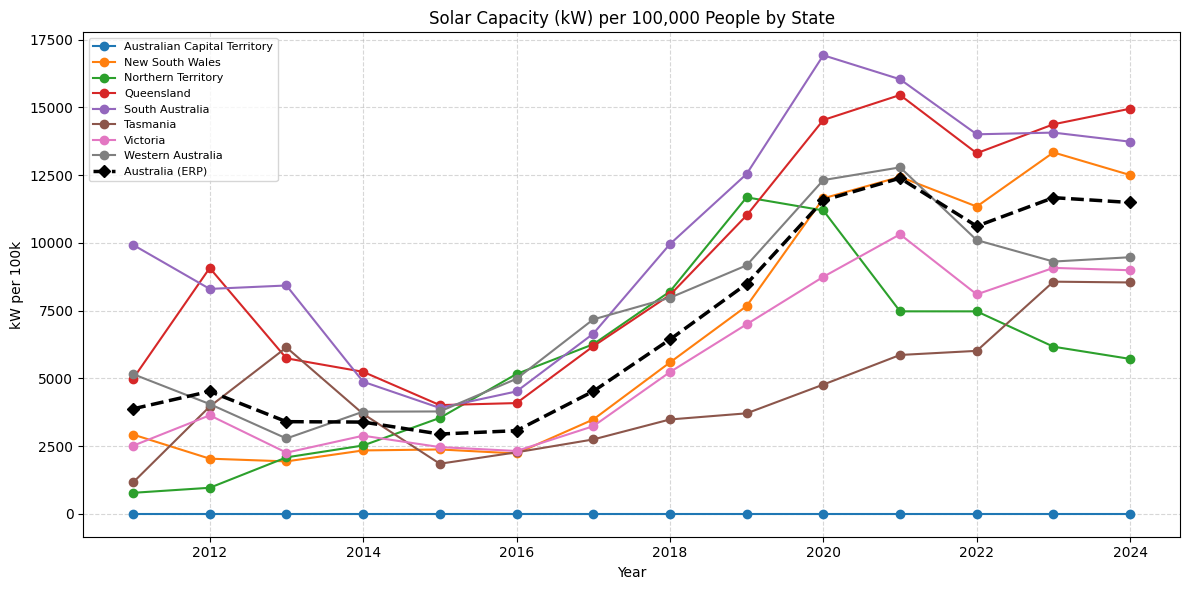

In [4]:
import matplotlib.pyplot as plt

df_aus = df_state_final.groupby("Year")[["Installations", "Capacity_kW", "Population"]].sum().reset_index()
df_aus["Installations_per_100k"] = df_aus["Installations"] / df_aus["Population"] * 100_000
df_aus["Capacity_per_100k"] = df_aus["Capacity_kW"] / df_aus["Population"] * 100_000

states = df_state_final["State"].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 6))
for i, state in enumerate(sorted(states)):
    data = df_state_final[df_state_final["State"] == state].sort_values("Year")
    ax.plot(data["Year"], data["Installations_per_100k"],
            marker="o", label=state, color=colors[i % len(colors)])

ax.plot(df_aus["Year"], df_aus["Installations_per_100k"],
        marker="D", linewidth=2.5, linestyle="--", color="black", label="Australia (ERP)")

ax.set_title("Solar Installations per 100,000 People by State")
ax.set_xlabel("Year")
ax.set_ylabel("Installations per 100k")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
for i, state in enumerate(sorted(states)):
    data = df_state_final[df_state_final["State"] == state].sort_values("Year")
    ax.plot(data["Year"], data["Capacity_per_100k"],
            marker="o", label=state, color=colors[i % len(colors)])

ax.plot(df_aus["Year"], df_aus["Capacity_per_100k"],
        marker="D", linewidth=2.5, linestyle="--", color="black", label="Australia (ERP)")

ax.set_title("Solar Capacity (kW) per 100,000 People by State")
ax.set_xlabel("Year")
ax.set_ylabel("kW per 100k")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Analysis and Findings 
Solar adoption has increased significantly since 2011, with variation across states. South Australia is the State that led the other states throughout the data timeframe. This attribute is most likely connected to the fact that South Australia is a state that has a long period of sun and more clearer sky compared to some of the other states. And the continuous trend in capacity shows that the growth is consistent with the population of Australia as a whole. This can be explained that the growth for solar is consistent and controlled.


# Discussion 
The results indicate a strong and sustained increase in solar adoption across Australia.

## Key Implications:
- Solar energy is becoming more accessible and widely adopted
- Growth is consistent with the population 
- Increased capacity suggests technological advancement and higher efficiency systems
## Potential Influencing Factors:
- Government incentives and rebates
- Decreasing cost of solar panels
- Increased environmental awareness
- Energy price pressures

## Differences between states may exist due to:

- Climate conditions
- Policy differences
- Economic factors


# Recommendations 
Based on the findings, the following recommendations are proposed for ARENA:

For future policy and investment, ARENA should continue with financial incentives for solar adoption. This will ensure that the solar adoption throughout Australia will stay consistent. Focus on underperforming states such as ACT, NT and WA.

There should also be further research on the correlation between incentives and adoption rates. And ARENA should research more into the impact of battery storage adoption.


# References 
- Australian solar installation dataset
- Australian solar capacity dataset
- Australian population dataset (https://www.abs.gov.au/census/find-census-data/datapacks)
- Python Pandas
- Matplotlib
